In [17]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [15]:
# Bootstrapping with optional weighting
def weighted_bootstrap(data, func=np.mean, weights=None, n_resamples=1000, rng=None):
    '''
    Perform weighted bootstrapping on input data to estimate confidence intervals for a given statistic.

    Parameters:
    -----------
    data : array-like
        The data from which to draw bootstrap samples.
    func : function, optional
        A function to compute the statistic of interest (e.g., np.mean, np.median). Default is np.mean.
    weights : array-like, optional
        Weights for weighted resampling. If None, uniform weights are used. Must be the same length as data.
    n_resamples : int, optional
        Number of bootstrap resamples. Default is 1000.
    rng : np.random.Generator, optional
        A NumPy random number generator. If None, a new default generator is created.

    Returns:
    --------
    ci : ndarray
        The 95% confidence interval (2.5th and 97.5th percentiles) of the bootstrapped statistic.
    '''

    # Create a default random number generator if none is provided
    rng = np.random.default_rng() if rng is None else rng

    # If no weights are provided, use equal weights
    if weights is None:
        weights = np.ones(len(data))

    # Generate bootstrap samples by randomly selecting elements with replacement,
    # using the provided weights as sampling probabilities
    bootstrap_samples = rng.choice(
        data,
        size=(n_resamples, len(data)),
        replace=True,
        p=weights / np.sum(weights),  # Normalize weights to sum to 1
        axis=0
    )

    # Apply the statistic function to each resample along the axis of resampling
    statistic = func(bootstrap_samples, axis=0)
    stat = np.average(statistic, axis=0)

    # Compute the 95% confidence interval (2.5th and 97.5th percentiles)
    ci = np.percentile(statistic, [2.5, 97.5], axis=0)

    return stat, ci

(100, 100)
2


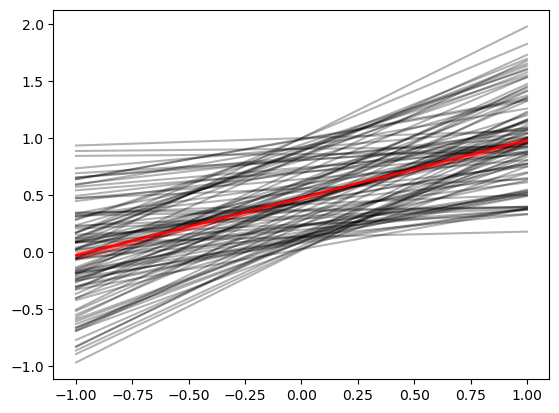

In [16]:
data_points = np.random.random(size=100)
data_points_1 = np.random.random(size=100)

data_lines = np.array([k*np.linspace(-1, 1, 100) + n for (k, n) in zip(data_points, data_points_1)])
print(data_lines.shape)


stat, ci = weighted_bootstrap(data_lines)
print(len(ci))

for i in range(len(data_lines)):
    plt.plot(np.linspace(-1, 1, 100), data_lines[i], '-k', alpha=0.3)

plt.plot(np.linspace(-1, 1, 100), stat, 'r-')
plt.fill_between(np.linspace(-1, 1, 100), ci[0], ci[1], color='r', alpha = 0.5)

plt.show()

2


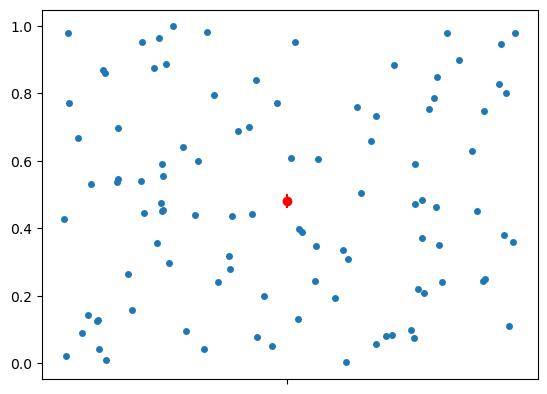

In [19]:
data_points = np.random.random(size=100)


stat, ci = weighted_bootstrap(data_points)
print(len(ci))

sns.stripplot(data_points)
plt.plot(0, stat, 'ro')
plt.plot([0, 0], ci, 'r-')

plt.show()